All classes.

In [10]:
import torch
import pandas as pd

folder = f"cifar10_22500"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
print("Keys: " + str(eval_qr_results.keys()))

# Find the closest quantile to the FPR threshold on nonmembers.
def get_tprs(eval_qr_results, train_qr_results, fpr):
    eval_preds = eval_qr_results['outputs'] < eval_qr_results['targets']
    fprs = torch.sum(eval_preds, dim=0) / eval_preds.shape[0]
    best_q_idx = torch.argmin(torch.abs(fprs - fpr))

    # Evaluate the per-class TPR on members using the best quantile found above.
    train_preds = train_qr_results['outputs'] < train_qr_results['targets']
    class_tprs = []
    for i in pd.unique(train_qr_results['labels'].numpy()):
        class_preds = train_preds[train_qr_results['labels'] == i]
        class_tpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
        class_tprs.append(class_tpr[best_q_idx].item())
    
    class_fprs = []
    for i in pd.unique(eval_qr_results['labels'].numpy()):
        class_preds = eval_preds[eval_qr_results['labels'] == i]
        class_fpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
        class_fprs.append(class_fpr[best_q_idx].item())
    return fprs[best_q_idx].item(), class_tprs, class_fprs

fpr = 0.01
fpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)
print(f"FPR: {fpr:.4f}")
print("Class TPRs: " + str([f"{tpr:.4f}" for tpr in class_tprs]))
print("Class FPRs: " + str([f"{fpr:.4f}" for fpr in class_fprs]))

Keys: dict_keys(['images', 'labels', 'outputs', 'targets'])
FPR: 0.0110
Class TPRs: ['0.7232', '0.8184', '0.5600', '0.7216', '0.5268', '0.7508', '0.4056', '0.7868', '0.7176', '0.7664']
Class FPRs: ['0.0164', '0.0132', '0.0128', '0.0100', '0.0116', '0.0076', '0.0136', '0.0068', '0.0156', '0.0028']


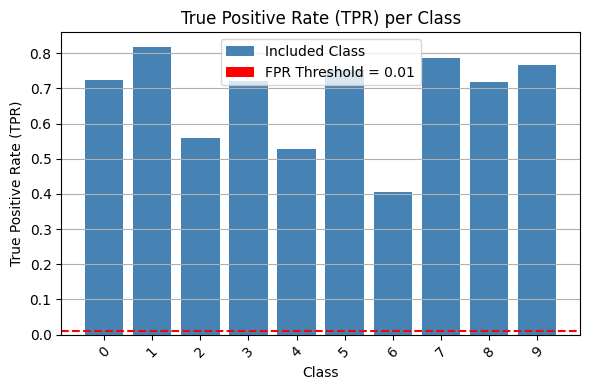

Average TPR across all classes:  0.6777200043201447


In [11]:
import numpy as np
from matplotlib.patches import Patch

# Plot the TPR for each class
import matplotlib.pyplot as plt

# Determine the colors for each class based on whether they are excluded
colors = ['steelblue' for cls in range(len(class_tprs))]

plt.figure(figsize=(6, 4))
plt.bar(range(len(class_tprs)), class_tprs, color=colors, tick_label=list(range(len(class_tprs))))
plt.xticks(rotation=45)
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate (TPR) per Class')

# Create custom legends for excluded and included classes
legend_elements = [Patch(facecolor='steelblue', label='Included Class'),
                   Patch(facecolor='r', linestyle='--', label='FPR Threshold = 0.01')]
plt.legend(handles=legend_elements)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Average TPR across all classes: ", np.mean(class_tprs))

Excluding 1 class.

In [12]:
import torch
import pandas as pd

num_exclude = 2
folder = f"cifar10_excludeclass{num_exclude}"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
print("Keys: " + str(eval_qr_results.keys()))

# Find the closest quantile to the FPR threshold on nonmembers.
fpr = 0.01
fpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)
print(f"FPR: {fpr:.4f}")
print("Class TPRs: " + str([f"{tpr:.4f}" for tpr in class_tprs]))
print("Class FPRs: " + str([f"{fpr:.4f}" for fpr in class_fprs]))

Keys: dict_keys(['images', 'labels', 'outputs', 'targets'])
FPR: 0.0096
Class TPRs: ['0.6976', '0.8416', '0.5248', '0.6952', '0.4856', '0.7384', '0.3816', '0.7968', '0.7148', '0.8080']
Class FPRs: ['0.0104', '0.0084', '0.0388', '0.0052', '0.0080', '0.0072', '0.0044', '0.0056', '0.0060', '0.0024']


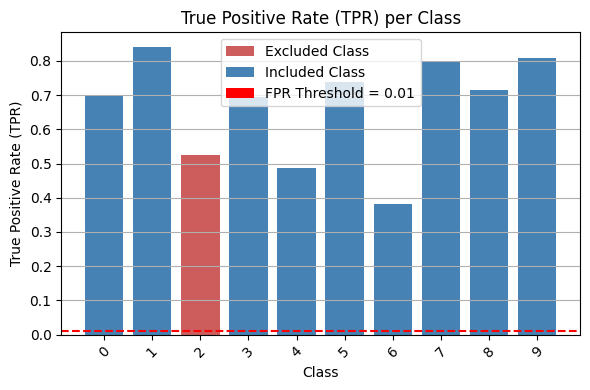

Average TPR across all classes:  0.6684400051832199


In [13]:
import numpy as np
from matplotlib.patches import Patch

# Identify the missing classes
# all_excluded_classes = np.load(f't_errors/cifar10/excluded_classes.npz', allow_pickle=True)
# excluded_classes = all_excluded_classes['excluded_classes'][num_exclude][0]
excluded_classes = [num_exclude]

# Plot the TPR for each class
import matplotlib.pyplot as plt

# Determine the colors for each class based on whether they are excluded
colors = ['indianred' if cls in excluded_classes else 'steelblue' for cls in range(len(class_tprs))]

plt.figure(figsize=(6, 4))
plt.bar(range(len(class_tprs)), class_tprs, color=colors, tick_label=list(range(len(class_tprs))))
plt.xticks(rotation=45)
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate (TPR) per Class')

# Create custom legends for excluded and included classes
legend_elements = [Patch(facecolor='indianred', label='Excluded Class'),
                   Patch(facecolor='steelblue', label='Included Class'),
                   Patch(facecolor='r', linestyle='--', label='FPR Threshold = 0.01')]
plt.legend(handles=legend_elements)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# print("Average TPR for included classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i not in excluded_classes]))
# print("Average TPR for excluded classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i in excluded_classes]))
print("Average TPR across all classes: ", np.mean(class_tprs))

Summary plot 1.

In [49]:
folder = f"cifar10_22500"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

base_fpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)

excluded_tprs = []
excluded_fprs = []
for cls in np.arange(0, 10):
    folder = f"cifar10_excludeclass{cls}"
    eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
    train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
    fpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)
    excluded_tprs.append(class_tprs[cls])
    excluded_fprs.append(class_fprs[cls])

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")
print()
print(f"Excluded TPRs: {[f'{tpr:.4f}' for tpr in excluded_tprs]}")
print(f"Excluded FPRs: {[f'{fpr:.4f}' for fpr in excluded_fprs]}")

Base TPRs: ['0.7232', '0.8184', '0.5600', '0.7216', '0.5268', '0.7508', '0.4056', '0.7868', '0.7176', '0.7664']
Base FPRs: ['0.0164', '0.0132', '0.0128', '0.0100', '0.0116', '0.0076', '0.0136', '0.0068', '0.0156', '0.0028']

Excluded TPRs: ['0.6344', '0.8856', '0.5472', '0.7200', '0.4540', '0.7096', '0.3852', '0.8084', '0.7652', '0.6132']
Excluded FPRs: ['0.0284', '0.0576', '0.0436', '0.0420', '0.0428', '0.0104', '0.0356', '0.0408', '0.0340', '0.0056']


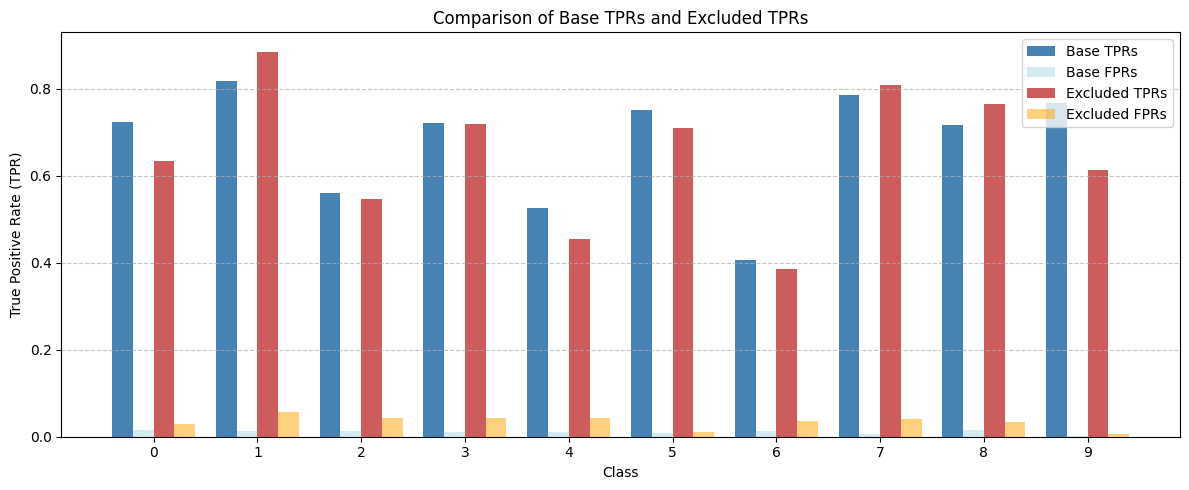

In [ ]:
def plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs):
    ind = np.arange(10)  # positions for classes 0 to 9
    width = 0.3         # width of the bars

    plt.figure(figsize=(12, 5))
    plt.bar(ind - 1.5*width, base_tprs, width, label='Base TPRs', color='steelblue')
    plt.bar(ind - 0.5*width, base_fprs, width, label='Base FPRs', color='lightblue', alpha=0.5)
    plt.bar(ind + 0.5*width, excluded_tprs, width, label='Excluded TPRs', color='indianred')
    plt.bar(ind + 1.5*width, excluded_fprs, width, label='Excluded FPRs', color='orange', alpha=0.5)
    plt.xlabel('Class')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Comparison of Base TPRs and Excluded TPRs')
    plt.xticks(ind)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs)

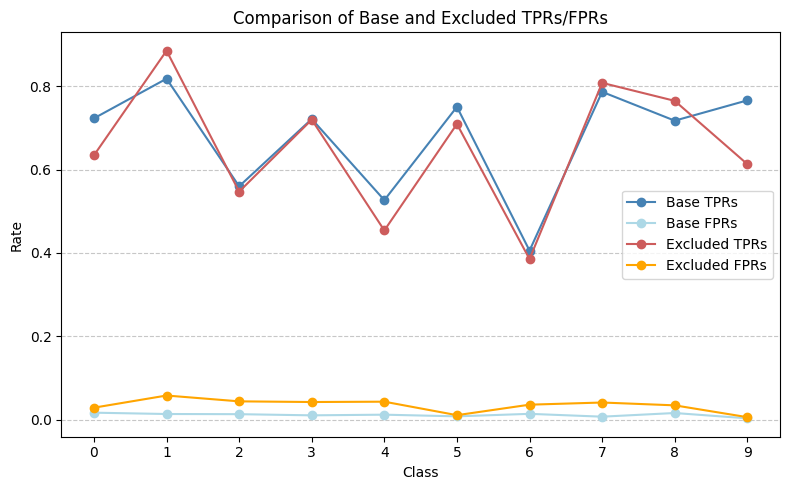

In [38]:
def line_plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs):
    ind = np.arange(10)  # positions for classes 0 to 9

    plt.figure(figsize=(8, 5))
    plt.plot(ind, base_tprs, marker='o', color='steelblue', label='Base TPRs')
    plt.plot(ind, base_fprs, marker='o', color='lightblue', label='Base FPRs')
    plt.plot(ind, excluded_tprs, marker='o', color='indianred', label='Excluded TPRs')
    plt.plot(ind, excluded_fprs, marker='o', color='orange', label='Excluded FPRs')

    plt.xlabel('Class')
    plt.ylabel('Rate')
    plt.title('Comparison of Base and Excluded TPRs/FPRs')
    plt.xticks(ind)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

line_plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs)

Summary Plot 2.

In [39]:
# Find the closest quantile to the FPR threshold on nonmembers SPECIFICALLY from a certain class.
def get_class_tpr(eval_qr_results, train_qr_results, class_i, fpr):
    eval_preds = eval_qr_results['outputs'] < eval_qr_results['targets']
    class_preds = eval_preds[eval_qr_results['labels'] == class_i]

    fprs = torch.sum(class_preds, dim=0) / class_preds.shape[0]
    best_q_idx = torch.argmin(torch.abs(fprs - fpr))

    # Evaluate the per-class TPR on members using the best quantile found above.
    train_preds = train_qr_results['outputs'] < train_qr_results['targets']
    class_preds = train_preds[train_qr_results['labels'] == class_i]
    class_tpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
    tpr = class_tpr[best_q_idx].item()

    return fprs[best_q_idx].item(), tpr

In [41]:
folder = f"cifar10_22500"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

base_fpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)

class_excluded_tprs = []
class_excluded_fprs = []
for cls in np.arange(0, 10):
    folder = f"cifar10_excludeclass{cls}"
    eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
    train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
    fpr, tpr = get_class_tpr(eval_qr_results, train_qr_results, cls, fpr)
    class_excluded_tprs.append(tpr)
    class_excluded_fprs.append(fpr)

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")
print()
print(f"Excluded TPRs: {[f'{tpr:.4f}' for tpr in class_excluded_tprs]}")
print(f"Excluded FPRs: {[f'{fpr:.4f}' for fpr in class_excluded_fprs]}")

Base TPRs: ['0.7232', '0.8184', '0.5600', '0.7216', '0.5268', '0.7508', '0.4056', '0.7868', '0.7176', '0.7664']
Base FPRs: ['0.0164', '0.0132', '0.0128', '0.0100', '0.0116', '0.0076', '0.0136', '0.0068', '0.0156', '0.0028']

Excluded TPRs: ['0.4252', '0.0876', '0.2860', '0.4820', '0.2184', '0.6872', '0.1916', '0.5080', '0.6308', '0.7504']
Excluded FPRs: ['0.0112', '0.0112', '0.0112', '0.0124', '0.0084', '0.0088', '0.0092', '0.0104', '0.0108', '0.0108']


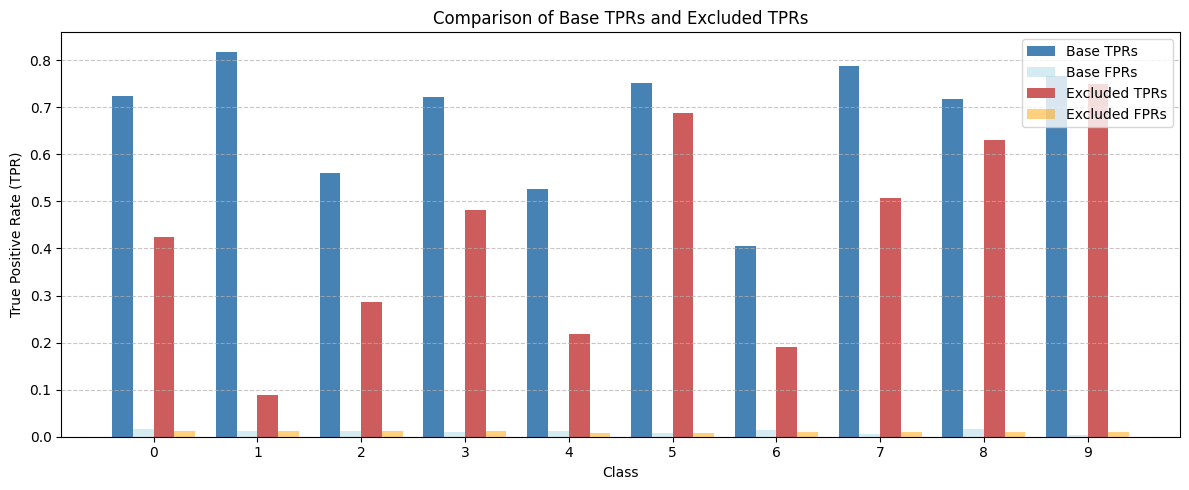

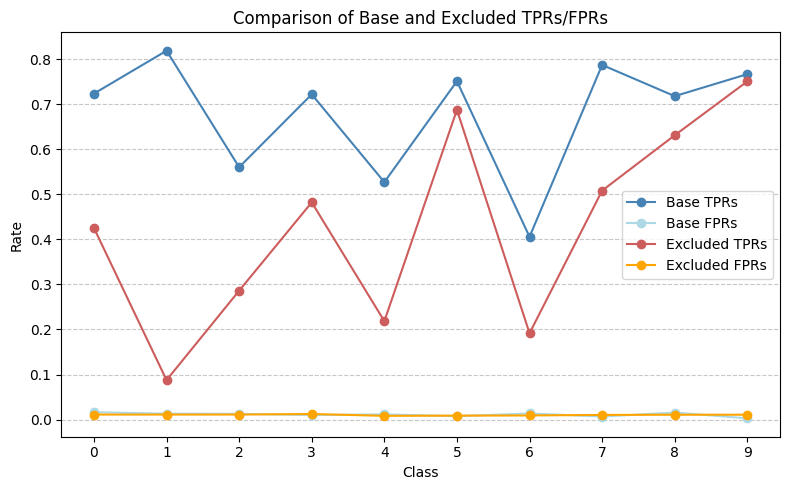

In [42]:
plot_comparison(base_tprs, base_fprs, class_excluded_tprs, class_excluded_fprs)
line_plot_comparison(base_tprs, base_fprs, class_excluded_tprs, class_excluded_fprs)

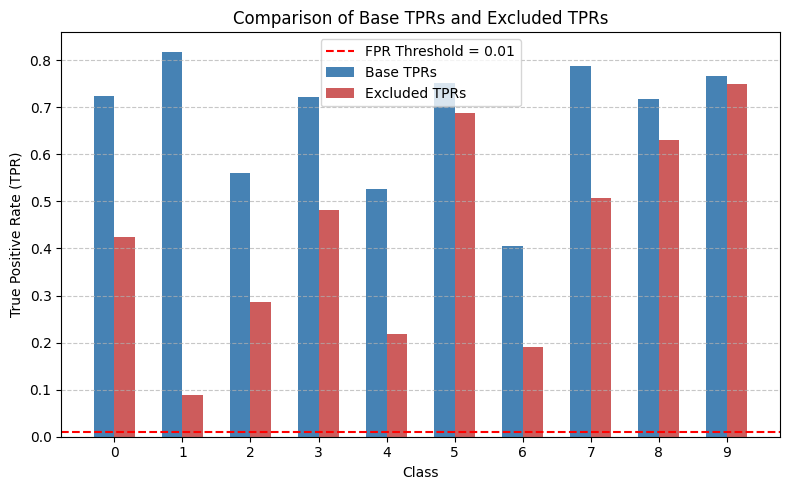

In [48]:
ind = np.arange(10)  # positions for classes 0 to 9
width = 0.3         # width of the bars

plt.figure(figsize=(8, 5))
plt.bar(ind - 0.5*width, base_tprs, width, label='Base TPRs', color='steelblue')
plt.bar(ind + 0.5*width, class_excluded_tprs, width, label='Excluded TPRs', color='indianred')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.title('Comparison of Base TPRs and Excluded TPRs')
plt.xticks(ind)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()